IMPORT

In [14]:
from PIL import Image, ImageEnhance, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
from transformers import pipeline

FOGGY AUXILIARY FUNCTIONS

In [2]:
def enhances(img, saturation, brightness, contrast, alpha):

    saturation_factor = 1 + (saturation - 1) * alpha
    brightness_factor = 1 + (brightness - 1) * alpha
    contrast_factor = 1 + (contrast - 1) * alpha

    # Apply saturation enhancement
    enhancer = ImageEnhance.Color(img)
    img_2 = enhancer.enhance(saturation_factor)

    # Apply brightness enhancement
    enhancer2 = ImageEnhance.Brightness(img_2)
    img_2 = enhancer2.enhance(brightness_factor)

    # Apply contrast enhancement
    enhancer3 = ImageEnhance.Contrast(img_2)
    img_2 = enhancer3.enhance(contrast_factor)

    return img_2

In [3]:
def get_fog(depth_image,color, vis=0.5):

    enhancer = ImageEnhance.Brightness(depth_image)
    depth_image = enhancer.enhance(30*(vis**3))     # Rescale the depth
    depth_array = np.array(depth_image)

    fog_layer = Image.new('RGBA', depth_image.size, color)
    fog_array = np.array(fog_layer)

    noise = np.random.normal(0,3, (depth_image.size[1],depth_image.size[0]))
    noise = noise.astype(np.uint8)
    fog_array[:, :, 0] += noise  # Red channel
    fog_array[:, :, 1] += noise  # Green channel
    fog_array[:, :, 2] += noise  # Blue channel
    fog_array[:, :, 0] = np.clip(fog_array[:, :, 0], 0, 255)
    fog_array[:, :, 1] = np.clip(fog_array[:, :, 1], 0, 255)
    fog_array[:, :, 2] = np.clip(fog_array[:, :, 2], 0, 255)
    fog_array[:, :, 3] = (255 - depth_array) # Set the alpha channel of the fog layer

    fog_layer_alpha = Image.fromarray(fog_array, 'RGBA')

    return fog_layer_alpha

In [4]:
def get_highlight(rgb_image,p=100):

    result = Image.new('RGBA', rgb_image.size, (0,0,0,0))

    result_array = np.array(result)
    image_array = np.array(rgb_image)

    brightness = 0.2126*image_array[:,:,0]+0.7152*image_array[:,:,1]+0.0722*image_array[:,:,2]

    mean_brightness = np.mean(brightness)

    result_array[:,:,0:3] = image_array
    result_array[:,:,3] = brightness*((brightness - mean_brightness)>p)

    result = Image.fromarray(result_array, 'RGBA')

    r, g, b, a = result.split()
    r = r.filter(ImageFilter.BLUR)
    g = g.filter(ImageFilter.BLUR)
    b = b.filter(ImageFilter.BLUR)
    result = Image.merge("RGBA", (r, g, b, a))

    return result

In [5]:
def get_color(image):

    img = np.array(image)
    mean = np.mean(img, axis = (0, 1))
    coeff = 0.2126*mean[0]+0.7152*mean[1]+0.0722*mean[2]
    n = -(1/255)*coeff*0.8 + 0.8
    color = n*np.append(mean, 0) + (1-n)*np.array([216, 216, 216, 0])
    color = color.astype(np.uint8)
    color = tuple(map(int,color))

    return color

In [6]:
def foggy(img,vis,pipe, night = False):

    color = get_color(img)

    depth = pipe(img)["depth"]

    img_enc = enhances(img,0.4,0.8,1.1, 1-vis)

    fog = get_fog(depth,color,vis)
    img_fog = Image.alpha_composite(img_enc.convert('RGBA'),fog)

    if night:
        highlight = get_highlight(img,70*vis +100)
        img_fog = Image.alpha_composite(img_fog.convert('RGBA'),highlight)

    img_fog = img_fog.convert('RGB')
    
    return img_fog

In [7]:
def display_images(images = [], image_names = [], rows = 1, cols = None):

    if cols is None:
        cols = len(images)
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, 3))

    axes = axes.flatten()

    for i in range(len(images)):
        axes[i].imshow(images[i])
        axes[i].axis('off')
        
        if image_names:
            axes[i].text(0.5, 1.05, image_names[i], ha='center', va='bottom', 
                         transform=axes[i].transAxes, fontsize=10, color='black', fontweight='bold')

    for j in range(len(images), len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

In [8]:
pipe = pipeline(task="depth-estimation",model="depth-anything/Depth-Anything-V2-Base-hf", device = 0)

Device set to use cpu


EXAMPLE AND IMAGE GENERATION FOR RAPPORT

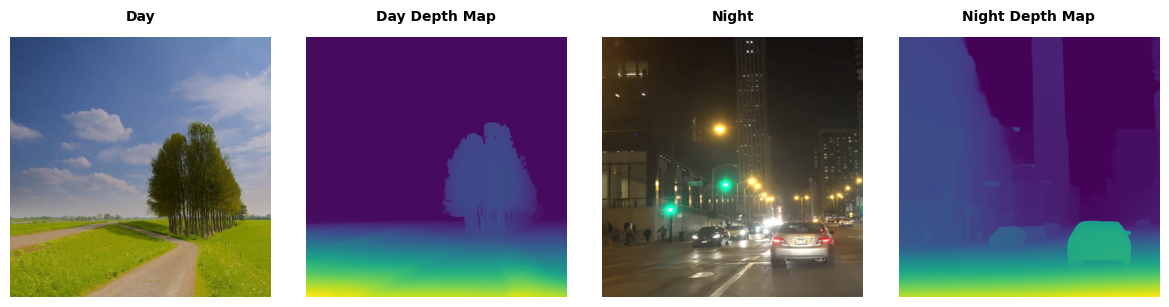

In [9]:
#Example
vis = 0.5
img_day = Image.open("resources/example/day (1).jpg").convert("RGB")
img_night = Image.open("resources/example/night (2).png").convert("RGB")

depth_day = pipe(img_day)["depth"]
depth_night = pipe(img_night)["depth"]

display_images([img_day,depth_day,img_night,depth_night],["Day", "Day Depth Map", "Night", "Night Depth Map"])

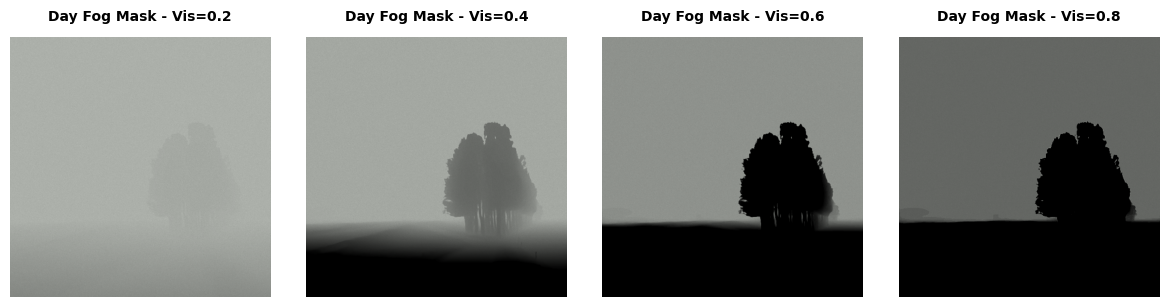

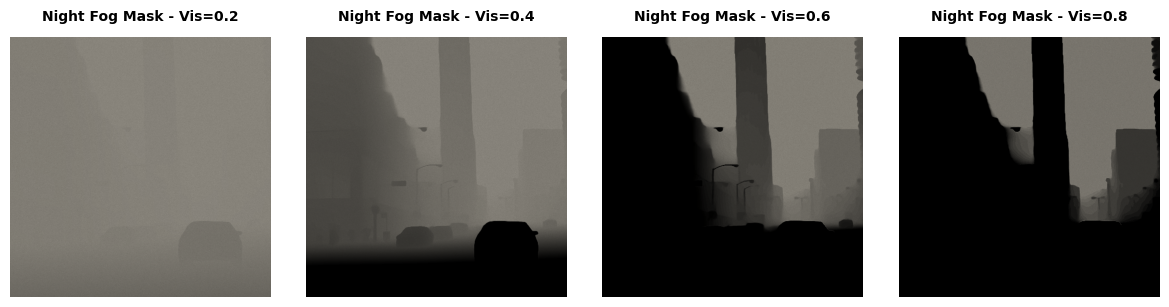

In [10]:
color_day = get_color(img_day)
fog_day_02 = get_fog(depth_day,color_day, vis=0.2)
fog_day_04 = get_fog(depth_day,color_day, vis=0.4)
fog_day_06 = get_fog(depth_day,color_day, vis=0.6)
fog_day_08 = get_fog(depth_day,color_day, vis=0.8)

black = Image.new("RGB", img_day.size, (0, 0, 0))
fog_day_02 = Image.alpha_composite(black.convert('RGBA'),fog_day_02)
fog_day_04 = Image.alpha_composite(black.convert('RGBA'),fog_day_04)
fog_day_06 = Image.alpha_composite(black.convert('RGBA'),fog_day_06)
fog_day_08 = Image.alpha_composite(black.convert('RGBA'),fog_day_08)

display_images([fog_day_02,fog_day_04,fog_day_06,fog_day_08],["Day Fog Mask - Vis=0.2", "Day Fog Mask - Vis=0.4", "Day Fog Mask - Vis=0.6", "Day Fog Mask - Vis=0.8"])

color_night = get_color(img_night)
fog_night_02 = get_fog(depth_night,color_night, vis=0.2)
fog_night_04 = get_fog(depth_night,color_night, vis=0.4)
fog_night_06 = get_fog(depth_night,color_night, vis=0.6)
fog_night_08 = get_fog(depth_night,color_night, vis=0.8)

black = Image.new("RGB", img_night.size, (0, 0, 0))
fog_night_02 = Image.alpha_composite(black.convert('RGBA'),fog_night_02)
fog_night_04 = Image.alpha_composite(black.convert('RGBA'),fog_night_04)
fog_night_06 = Image.alpha_composite(black.convert('RGBA'),fog_night_06)
fog_night_08 = Image.alpha_composite(black.convert('RGBA'),fog_night_08)


display_images([fog_night_02,fog_night_04,fog_night_06,fog_night_08],["Night Fog Mask - Vis=0.2", "Night Fog Mask - Vis=0.4", "Night Fog Mask - Vis=0.6", "Night Fog Mask - Vis=0.8"])

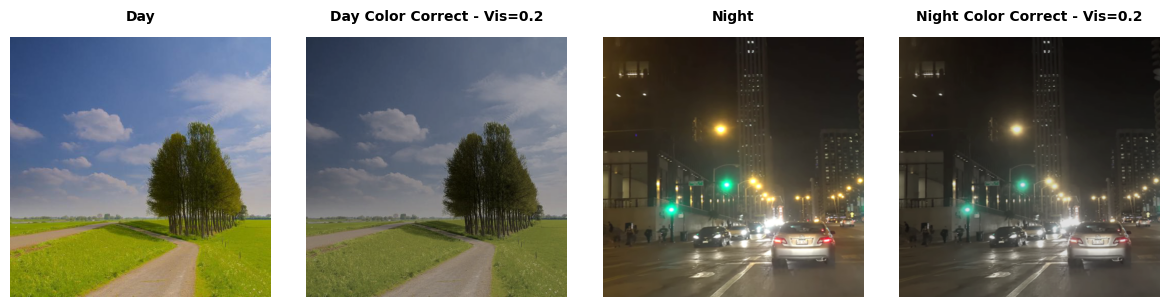

In [11]:
day_enc_02 = enhances(img_day,0.4,0.8,1.1, 1-0.2)
night_enc_02 = enhances(img_night,0.4,0.8,1.1, 1-0.2)
display_images([img_day,day_enc_02,img_night,night_enc_02 ],["Day", "Day Color Correct - Vis=0.2", "Night", "Night Color Correct - Vis=0.2"])

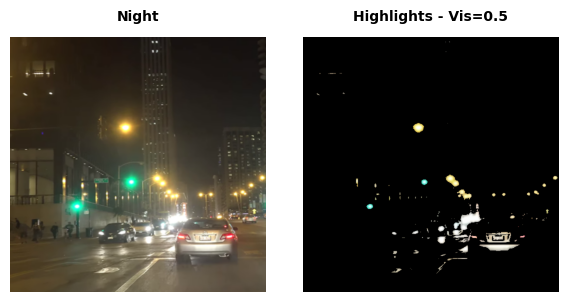

In [12]:
night_light = get_highlight(img_night,70*0.5 +100)
black = Image.new("RGB", img_night.size, (0, 0, 0))
night_light = Image.alpha_composite(black.convert('RGBA'),night_light)
display_images([img_night,night_light],["Night", "Highlights - Vis=0.5"])

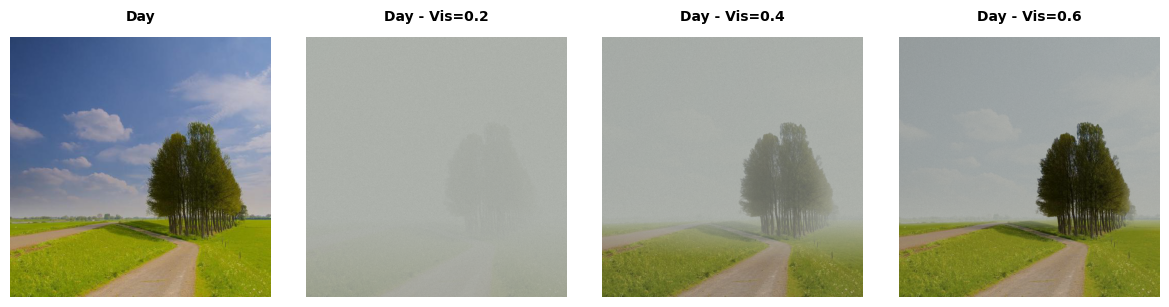

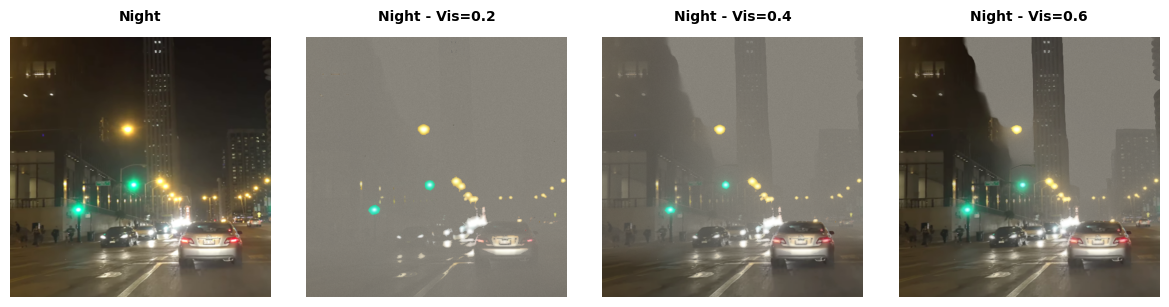

In [13]:
day_foggy_02 = foggy(img_day,0.2,pipe,False)
day_foggy_04 = foggy(img_day,0.4,pipe,False)
day_foggy_06 = foggy(img_day,0.6,pipe,False)
display_images([img_day,day_foggy_02,day_foggy_04,day_foggy_06],["Day", "Day - Vis=0.2", "Day - Vis=0.4", "Day - Vis=0.6"])

night_foggy_02 = foggy(img_night,0.2,pipe,True)
night_foggy_04 = foggy(img_night,0.4,pipe,True)
night_foggy_06 = foggy(img_night,0.6,pipe,True)
display_images([img_night,night_foggy_02,night_foggy_04,night_foggy_06],["Night", "Night - Vis=0.2", "Night - Vis=0.4", "Night - Vis=0.6"])